# Import and/or install libraries: 

In [19]:
import numpy as np

from pathlib import Path
from struct import unpack

import seaborn as sns
import matplotlib.pyplot as plt


# Load data:

# Plot comparison:

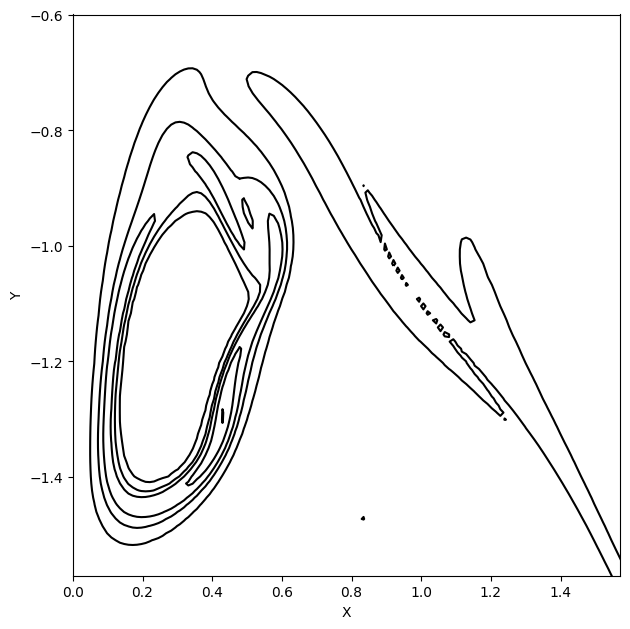

In [28]:
# Create coordinate grids
n_points = 512
dx = 2 * np.pi / n_points
x = np.arange(-np.pi, np.pi - dx, dx)
y = np.arange(-np.pi, np.pi - dx, dx)

# Initialize data array
w = np.zeros((len(y), len(x)))

# Load binary data
data_file = Path('../Data/NASA_workshop_validation/C3.3_datafiles/wn_slice_x0_08000.out')
with open(data_file, 'rb') as file:
    data = file.read()

# Read data into array
n = 0
for i in range(len(x)):
    for j in range(len(y)):
        value = unpack('d', data[n:n+8])[0]
        w[j, i] = value
        n += 8

# Create contour plot
fig, ax = plt.subplots(figsize=(6.4, 6.4), dpi=100)
contours = ax.contour(x, y, w, levels=[1, 5, 10, 20, 30], colors='k')

# Set axis limits
ax.set_xlim(0, np.pi/2)
ax.set_ylim(-np.pi/2, -0.6)

# Add colorbar and labels
#plt.colorbar(contours)
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.tight_layout()
plt.show()

# NASA original code bkp:

## Full domain

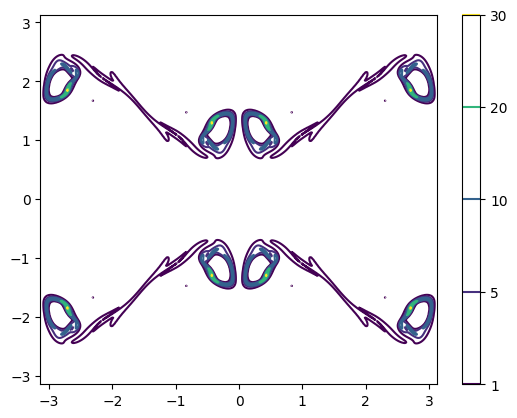

In [6]:
#! /usr/bin/env python
# -*- coding: UTF-8 -*-
# Small python script to extract and plot
# the data contained in the file wn_slice_x0_08000.out
# Other example of script:
#  f = fopen(file, "rb") ;
#  for i
#   for j
#     fread(W(i,j), 1, sizeof(double), f)
#   end
#  end


from numpy import *

import pylab as p
from struct import *

Pi = arccos(-1)
x = arange(-Pi,Pi-2.*Pi/512.,2.*Pi/512.)
y = arange(-Pi,Pi-2.*Pi/512.,2.*Pi/512.)

size = (len(x),len(y))

w = zeros(size)

file = open('../Data/NASA_workshop_validation/C3.3_datafiles/wn_slice_x0_08000.out', 'rb')
data = file.read()

n = 0
for i in range(len(x)):
  for j in range(len(y)):
    a = unpack('d', data[n:n+8])
    w[j][i] = a[0]
    n = n+8

fig=p.figure()
p.contour(x,y,w, levels = [1,5,10,20,30])
#p.axis('normal')
p.colorbar()
p.show()


## Only the non periodic domain:

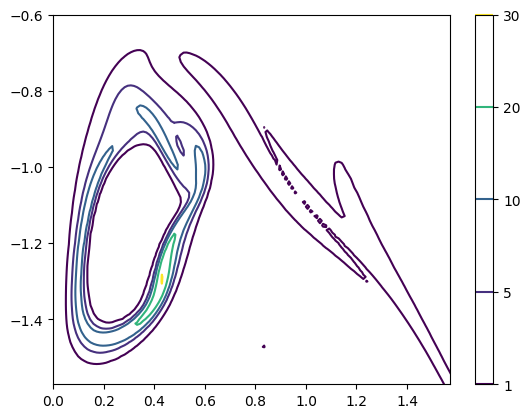

In [17]:
#! /usr/bin/env python
# -*- coding: UTF-8 -*-
# Small python script to extract and plot
# the data contained in the file wn_slice_x0_08000.out
# Other example of script:
#  f = fopen(file, "rb") ;
#  for i
#   for j
#     fread(W(i,j), 1, sizeof(double), f)
#   end
#  end


from numpy import *

import pylab as p
from struct import *

Pi = arccos(-1)
x = arange(-Pi,Pi-2.*Pi/512.,2.*Pi/512.)
y = arange(-Pi,Pi-2.*Pi/512.,2.*Pi/512.)

size = (len(x),len(y))

w = zeros(size)

file = open('../Data/NASA_workshop_validation/C3.3_datafiles/wn_slice_x0_08000.out', 'rb')
data = file.read()

n = 0
for i in range(len(x)):
  for j in range(len(y)):
    a = unpack('d', data[n:n+8])
    w[j][i] = a[0]
    n = n+8

fig=p.figure()

p.contour(x,y,w, levels = [1,5,10,20,30])
#p.axis('normal')

plt.xlim(0, 2*pi/4)  # Set x-axis limits
plt.ylim(-2*pi/4, -0.6)  # Set y-axis limits

p.colorbar()
p.show()
